# Terra-Sat-Drift: Interactive Examples Notebook

This notebook provides an interactive environment to run and debug Terra-Sat-Drift examples iteratively. You can run each section independently to test different drift analysis scenarios.

**Available Examples:**
1. Classification-Only Drift Analysis
2. Segmentation-Only Drift Analysis
3. Combined Classification + Segmentation Drift Analysis
4. Full Pipeline End-to-End Analysis
5. Custom Configuration with Device Setup

## 1. Import Required Libraries and Setup

Import all necessary dependencies and configure the environment. This cell sets up GPU/CPU detection and basic configuration.

In [1]:
# Import Required Libraries
from terra_sat_drift.model_tasks import (
    TerraMindClassifier,
    TerraMindSegmenter,
)
from pathlib import Path
import numpy as np
import rasterio
import torch

# Configure environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("GPU not available, using CPU")

/shared/home/elucas/terra-sat-drift/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/shared/home/elucas/terra-sat-drift/terra_sat_drift/data_simulation/phisat2_constants.py:37: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  WORLD_GDF = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


Using device: cuda
PyTorch version: 2.10.0+cu128
GPU: NVIDIA A100-SXM4-40GB MIG 1g.10gb
GPU Memory: 10.47 GB


In [2]:
from terra_sat_drift.drift_analysis import (
    DriftAnalyzer, ClassificationDriftAnalyzer, DriftPipeline
)


## 2. Initialize Classification Service

Create and configure a TerraMindClassifier instance. You can adjust the number of classes and backbone size for different use cases.

In [3]:
# Initialize Classification Service
num_classes = 10
backbone_size = "base"

classifier = TerraMindClassifier(
    num_classes=num_classes, 
    backbone_size=backbone_size,
    device=device
)

print(f"✓ Classifier initialized")
print(f"  - Number of classes: {classifier.num_classes}")
print(f"  - Backbone size: {backbone_size}")
print(f"  - Device: {device}")

✓ Classifier initialized
  - Number of classes: 10
  - Backbone size: base
  - Device: cuda


## 3. Initialize Segmentation Service

Create and configure a TerraMindSegmenter instance for semantic segmentation. Can be used for binary or multi-class segmentation.

In [4]:
# Initialize Segmentation Service
# Binary segmentation: background vs foreground (change to 4+ for multi-class)
seg_num_classes = 2  # Binary: background vs foreground
seg_backbone_size = "base"

segmenter = TerraMindSegmenter(
    num_classes=seg_num_classes,
    backbone_size=seg_backbone_size,
    device=device
)

print(f"✓ Segmenter initialized")
print(f"  - Number of classes: {segmenter.num_classes}")
print(f"  - Backbone size: {seg_backbone_size}")
print(f"  - Device: {device}")
print(f"\nAvailable backbone sizes: base, large")
print(f"For multi-class segmentation, change seg_num_classes parameter")

✓ Segmenter initialized
  - Number of classes: 2
  - Backbone size: base
  - Device: cuda

Available backbone sizes: base, large
For multi-class segmentation, change seg_num_classes parameter


## 4. Classification-Only Drift Analysis

Run classification predictions on a single Sentinel-2 image. Display predicted class, confidence scores, and top-3 predictions.

**Update the file path below to point to your Sentinel-2 TIFF image:**

In [ ]:
# Initialize classification drift analyzer
clf_analyzer = ClassificationDriftAnalyzer(classifier)

# Specify your Sentinel-2 image file paths
raw_file = Path("tiff_folder/raw_s2_cache/642220-5068670_32631_BANDS_RES-GRID_0_2025-07-15T10-48-25_052.tiff")
simulated_file = Path("tiff_folder/simulated_custom_l2_tiff/642220-5068670_32631_PHISAT2-BANDS-GRID_0_2025-07-15T10-48-25_052.tiff")

# Check if files exist
if raw_file.exists() and simulated_file.exists():
    print(f"\nAnalyzing classification drift between:")
    print(f"  Raw file: {raw_file.name}")
    print(f"  Simulated file: {simulated_file.name}\n")
    
    # Perform comprehensive classification drift analysis
    drift_results = clf_analyzer.analyze_drift(raw_file, simulated_file)
    
    print(f"\n{'='*80}")
    print("CLASSIFICATION DRIFT ANALYSIS RESULTS")
    print(f"{'='*80}\n")
    
    # Spectral Drift
    print("Spectral Drift:")
    spec_summary = drift_results['spectral_drift']['summary']
    print(f"  Avg mean difference: {spec_summary['avg_mean_difference']:.4f}")
    print(f"  Max mean difference: {spec_summary['max_mean_difference']:.4f}")
    print(f"  Avg std change: {spec_summary['avg_std_change']:.4f}")
    
    # Embedding Drift
    print(f"\nEmbedding Drift:")
    embed = drift_results['embedding_drift']
    print(f"  Cosine similarity: {embed['cosine_similarity']:.4f}")
    print(f"  MSE error: {embed['mse_error']:.6f}")
    print(f"  MAE error: {embed['mae_error']:.6f}")
    print(f"  Pixel max diff: {embed['pixel_max_diff']:.6f}")
    
    # Classification Drift
    print(f"\nClassification Drift:")
    class_drift = drift_results['class_drift']
    print(f"  Predicted class (raw): {class_drift['pred1_class']}")
    print(f"  Predicted class (simulated): {class_drift['pred2_class']}")
    print(f"  Class flip: {class_drift['class_flip']}")
    print(f"  Probability change: {class_drift['probability_change']:+.4f}")
    print(f"  Top-3 consistency: {class_drift['top3_consistency']:.4f}")
    print(f"  Raw confidence: {class_drift['pred1_probability']:.4f}")
    print(f"  Simulated confidence: {class_drift['pred2_probability']:.4f}")
    
    print(f"\n{'='*80}")
    print("Task:", drift_results['task'].upper())
    print(f"{'='*80}")
else:
    print(f"\n⚠ Files not found:")
    if not raw_file.exists():
        print(f"  ✗ Raw file: {raw_file}")
    if not simulated_file.exists():
        print(f"  ✗ Simulated file: {simulated_file}")


EXAMPLE 1: Classification-Only Drift Analysis

Prediction Results for: 642220-5068670_32631_PHISAT2-BANDS-GRID_0_2025-07-15T10-48-25_052.tiff
  Predicted class: 5
  Confidence: 0.1577
  Top 3 predictions: [(5, 0.1576976180076599), (4, 0.14518232643604279), (3, 0.12373179942369461)]


## 5. Segmentation-Only Drift Analysis

Perform semantic segmentation on an image and compute metrics against ground truth labels.

**Update file paths below to point to your data:**

In [12]:
# Example: Segmentation-Only Drift Analysis
print("\n" + "=" * 80)
print("EXAMPLE 2: Semantic Segmentation Only")
print("=" * 80)

# Update these paths to your actual data
s2_file = Path("datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/USA_1068362_S2Hand.tif")
simulated_file = Path("tiff_folder/simulated_sen1floods/simulated_train/simulated_USA_1068362_S2Hand.tif")
gt_file = Path("datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/USA_1068362_LabelHand.tif")

if s2_file.exists():
    # Segment the image
    print(f"\nSegmenting: {s2_file.name}")
    segmentation_result = segmenter.segment_image(s2_file)
    
    # Get segmentation map and probabilities
    seg_map = segmentation_result["segmentation"]  # (height, width)
    prob_map = segmentation_result["probability_map"]  # (height, width, num_classes)
    
    print(f"Segmentation shape: {seg_map.shape}")
    print(f"Probability map shape: {prob_map.shape}")
    print(f"Unique classes in segmentation: {np.unique(seg_map)}")
    
    # Load and compute metrics against ground truth if available
    if gt_file.exists():
        print(f"\nLoading ground truth: {gt_file.name}")
        with rasterio.open(gt_file) as src:
            ground_truth = src.read(1)
        
        metrics = segmenter.compute_segmentation_metrics(seg_map, ground_truth)
        
        print(f"\nSegmentation Metrics (vs Ground Truth):")
        print(f"  IoU: {metrics['iou']:.4f}")
        print(f"  Dice: {metrics['dice']:.4f}")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        
        # Segmentation Drift Analysis (if simulated file exists)
        if simulated_file.exists():
            print(f"\n{'='*80}")
            print("SEGMENTATION DRIFT ANALYSIS")
            print(f"{'='*80}")
            
            print(f"\nAnalyzing segmentation drift between:")
            print(f"  Raw file: {s2_file.name}")
            print(f"  Simulated file: {simulated_file.name}")
            
            # Initialize segmentation drift analyzer
            from terra_sat_drift.drift_analysis import SegmentationDriftAnalyzer
            seg_drift_analyzer = SegmentationDriftAnalyzer(classifier, segmenter)
            
            # Compute drift
            drift_results = seg_drift_analyzer.compare_segmentation(s2_file, simulated_file, ground_truth)
            
            print(f"\nSegmentation Drift Metrics:")
            print(f"  Raw segmentation metrics: {drift_results['raw_segmentation_metrics']}")
            print(f"  Simulated segmentation metrics: {drift_results['simulated_segmentation_metrics']}")
            print(f"Prediction agreement: {drift_results['prediction_agreement']}")
            print(f"  Drift metrics: {drift_results['drift_metrics']}")
            
        else:
            print(f"\n⚠ Simulated file not found: {simulated_file}")
            print("Skipping drift analysis. For drift analysis, provide both raw and simulated files.")
    else:
        print(f"\n⚠ Ground truth file not found: {gt_file}")
else:
    print(f"\n⚠ Sentinel-2 file not found: {s2_file}")
    print("Please update the file paths to point to your data")


EXAMPLE 2: Semantic Segmentation Only

Segmenting: USA_1068362_S2Hand.tif
Segmentation shape: (512, 512)
Probability map shape: (512, 512, 2)
Unique classes in segmentation: [0 1]

Loading ground truth: USA_1068362_LabelHand.tif

Segmentation Metrics (vs Ground Truth):
  IoU: 0.1356
  Dice: 0.2388
  Accuracy: 0.4509

SEGMENTATION DRIFT ANALYSIS

Analyzing segmentation drift between:
  Raw file: USA_1068362_S2Hand.tif
  Simulated file: simulated_USA_1068362_S2Hand.tif

Segmentation Drift Metrics:
  Raw segmentation metrics: {'iou': 0.13555911905491191, 'dice': 0.23875308080434116, 'accuracy': 0.4509429931640625, 'precision': 0.14295214450383806, 'recall': 0.7238470912706049, 'f1_score': 0.23875308080434113, 'confusion_matrix': {'true_positives': 22571, 'false_positives': 135321, 'true_negatives': 95641, 'false_negatives': 8611}}
  Simulated segmentation metrics: {'iou': 0.11670329767522078, 'dice': 0.2090139751860256, 'accuracy': 0.23805618286132812, 'precision': 0.11922995251584688, '

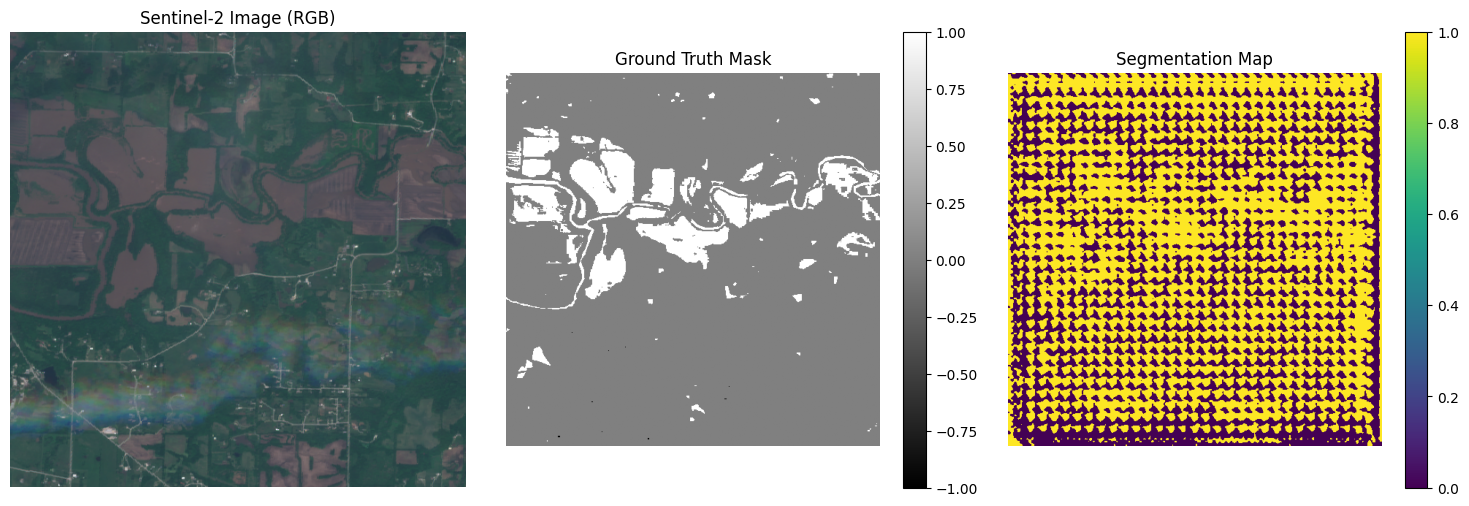

✓ Visualization complete
  S2 shape: (512, 512, 3)
  Ground truth shape: (512, 512)
  Segmentation shape: (512, 512)


In [6]:
# Visualize S2 image, ground truth, and segmentation map
import matplotlib.pyplot as plt

if s2_file.exists() and gt_file.exists():
    # Load S2 image (RGB bands: B4=Red, B3=Green, B2=Blue)
    with rasterio.open(s2_file) as src:
        s2_data = src.read([4, 3, 2]).astype(np.float32)  # RGB
        s2_rgb = np.transpose(s2_data, (1, 2, 0))
        # Normalize to 0-1 range for display
        s2_rgb = np.clip(s2_rgb / s2_rgb.max(), 0, 1)
    
    # Load ground truth
    with rasterio.open(gt_file) as src:
        gt_data = src.read(1).astype(np.float32)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot S2 image
    axes[0].imshow(s2_rgb)
    axes[0].set_title("Sentinel-2 Image (RGB)")
    axes[0].axis("off")
    
    # Plot ground truth
    gt_color = axes[1].imshow(gt_data, cmap="gray")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")
    plt.colorbar(gt_color, ax=axes[1])
    
    # Plot segmentation map
    seg_color = axes[2].imshow(seg_map, cmap="viridis")
    axes[2].set_title("Segmentation Map")
    axes[2].axis("off")
    plt.colorbar(seg_color, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Visualization complete")
    print(f"  S2 shape: {s2_rgb.shape}")
    print(f"  Ground truth shape: {gt_data.shape}")
    print(f"  Segmentation shape: {seg_map.shape}")
else:
    print("Files not found. Please run the segmentation cell first.")

## 6. Combined Drift Analysis with Both Services

Initialize a DriftAnalyzer with both classifier and segmenter to analyze comprehensive drift including spectral, embedding, classification, and segmentation components.

**Update file paths below:**

In [ ]:
# Example: Combined Drift Analysis
print("\n" + "=" * 80)
print("EXAMPLE 3: Combined Classification + Segmentation Drift Analysis")
print("=" * 80)

# Initialize drift analyzer with both services
analyzer = DriftAnalyzer(classifier, segmenter=segmenter)

# File pairs for drift analysis
raw_file = Path("path/to/raw_s2.tif")
simulated_file = Path("path/to/simulated_s2.tif")
ground_truth_file = Path("path/to/ground_truth.tif")

print(f"\nDrift Analyzer Configuration:")
print(f"  Using Classifier: {analyzer.classifier is not None}")
print(f"  Using Segmenter: {analyzer.segmenter is not None}")

# Check if files exist
if raw_file.exists() and simulated_file.exists():
    print(f"\nAnalyzing drift between:")
    print(f"  Raw file: {raw_file.name}")
    print(f"  Simulated file: {simulated_file.name}")
    
    try:
        # Analyze ALL drift types: spectral + embedding + segmentation
        comprehensive_drift = analyzer.analyze_drift_comprehensive(raw_file, simulated_file)
        
        print(f"\n{'='*80}")
        print("DRIFT ANALYSIS RESULTS")
        print(f"{'='*80}")
        
        print(f"\nSpectral Drift:")
        spec_summary = comprehensive_drift['spectral_drift']['summary']
        print(f"  Avg mean difference: {spec_summary['avg_mean_difference']:.4f}")
        print(f"  Max mean difference: {spec_summary['max_mean_difference']:.4f}")
        
        print(f"\nEmbedding Drift:")
        embed = comprehensive_drift['embedding_drift']
        print(f"  Cosine similarity: {embed['cosine_similarity']:.4f}")
        print(f"  MSE error: {embed['mse_error']:.6f}")
        print(f"  MAE error: {embed['mae_error']:.6f}")
        
        print(f"\nClassification Drift:")
        class_drift = comprehensive_drift['class_drift']
        print(f"  Class flip: {class_drift['class_flip']}")
        print(f"  Probability change: {class_drift['probability_change']:+.4f}")
        print(f"  Top-3 consistency: {class_drift['top3_consistency']:.4f}")
        
    except Exception as e:
        print(f"\n✗ Error during analysis: {e}")
        print("Check that model weights are available and files are valid")
else:
    print(f"\n⚠ Files not found. Please update the file paths:")
    print(f"  Raw file: {raw_file}")
    print(f"  Simulated file: {simulated_file}")

## 7. Full Pipeline End-to-End Analysis

Use the DriftPipeline for automated end-to-end drift analysis on the Sen1Floods dataset. This pipeline handles batch processing and automatic metric aggregation.

**Configure the dataset paths and parameters below:**

In [ ]:
# Example: Full Pipeline End-to-End Analysis
print("\n" + "=" * 80)
print("EXAMPLE 4: Using DriftPipeline for End-to-End Analysis")
print("=" * 80)

# Initialize pipeline (creates both classifier and segmenter internally)
print("\nInitializing DriftPipeline...")
pipeline = DriftPipeline(
    num_classes=10, 
    backbone_size="base",
    enable_segmentation=True,  # Set to False to skip segmentation
    device=device
)

print("✓ DriftPipeline initialized")
print(f"  - Segmentation enabled: True")
print(f"  - Device: {device}")

# Configure dataset paths
sen1floods_root = Path("./datasets/sen1floods11")
simulated_dir = Path("./tiff_folder/simulated_sen1floods")
split = "train"  # or "test"
num_samples = 10  # Set to None to analyze all samples

# Check if dataset exists
if sen1floods_root.exists() and simulated_dir.exists():
    print(f"\nDataset configuration:")
    print(f"  Sen1Floods root: {sen1floods_root}")
    print(f"  Simulated dir: {simulated_dir}")
    print(f"  Split: {split}")
    print(f"  Num samples: {num_samples}")
    
    print(f"\nRunning Sen1Floods drift analysis...")
    try:
        results = pipeline.run_sen1floods_drift_analysis(
            sen1floods_root=str(sen1floods_root),
            simulated_dir=str(simulated_dir),
            split=split,
            num_samples=num_samples,
        )
        
        print(f"\n✓ Analysis complete!")
        print(f"  Processed {len(results)} file pairs")
        
    except Exception as e:
        print(f"✗ Error during pipeline execution: {e}")
else:
    print(f"\n⚠ Dataset directories not found:")
    print(f"  Sen1Floods root: {sen1floods_root.exists()}")
    print(f"  Simulated dir: {simulated_dir.exists()}")
    print(f"\nPlease update paths and ensure data is available")

## 8. Custom Configuration and Device Setup

Demonstrate custom model configurations with different backbone sizes, device selection, and multi-class segmentation. Compare model parameters and memory usage.

In [ ]:
# Example: Custom Configuration and Device Setup
print("\n" + "=" * 80)
print("EXAMPLE 5: Custom Configuration and Device Setup")
print("=" * 80)

# Configuration options
print("\nAvailable backbone sizes: base, large")
print("Available devices:", end=" ")
if torch.cuda.is_available():
    print(f"cuda (GPU), cpu")
else:
    print("cpu only")

# Create custom configurations
configs = {
    "Base Model (Classification)": {
        "classifier": TerraMindClassifier(num_classes=10, backbone_size="base", device=device),
        "segmenter": None
    },
    "Large Model (Classification + Segmentation)": {
        "classifier": TerraMindClassifier(num_classes=10, backbone_size="large", device=device),
        "segmenter": TerraMindSegmenter(num_classes=4, backbone_size="large", device=device)  # 4 classes: water, vegetation, urban, other
    },
    "Multi-class Segmentation Only": {
        "classifier": None,
        "segmenter": TerraMindSegmenter(num_classes=5, backbone_size="base", device=device)  # 5-class segmentation
    }
}

print(f"\n{'='*80}")
print("MODEL CONFIGURATIONS")
print(f"{'='*80}\n")

for config_name, models in configs.items():
    print(f"\n{config_name}:")
    print(f"  Device: {device}")
    
    if models["classifier"] is not None:
        print(f"  Classifier:")
        print(f"    - Classes: {models['classifier'].num_classes}")
        print(f"    - Backbone: large" if "large" in str(models["classifier"]).lower() else "    - Backbone: base")
    
    if models["segmenter"] is not None:
        print(f"  Segmenter:")
        print(f"    - Classes: {models['segmenter'].num_classes}")
        print(f"    - Backbone: large" if "large" in str(models["segmenter"]).lower() else "    - Backbone: base")
    
    if torch.cuda.is_available():
        if models["classifier"] is not None:
            # Rough estimate - actual usage depends on batch size and image resolution
            print(f"    - Est. memory usage: ~2-4 GB")
        elif models["segmenter"] is not None:
            print(f"    - Est. memory usage: ~2-4 GB")

print(f"\n{'='*80}")
print("Combine configurations as needed:")
print("  analyzer = DriftAnalyzer(classifier, segmenter=segmenter)")
print(f"{'='*80}")